In [1]:
# import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from stop_utils import load_zemax_wfe

# from stop_utils import logger
# logger.remove()
# _=logger.add(sys.stderr, level="DEBUG")

In [2]:
# wfe_path = "../data/zemax/wfemap17fc.txt"
# wfe_path = "../data/zemax/wfemap01fc.txt"
wfe_path = "/home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt"
wfe = load_zemax_wfe(wfe_path)

2025-04-19 23:43:52 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:52 | INFO     | stop_utils.converters:load_zemax_wfe:101 - Successfully loaded and converted data from /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt


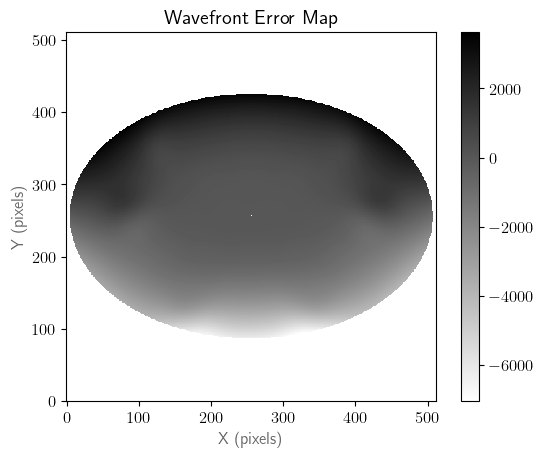

In [3]:
plt.figure()
wfe_masked = np.ma.masked_where(wfe == 0, wfe)
plt.imshow(wfe_masked, cmap="gray_r", interpolation="none", origin="lower")
plt.title("Wavefront Error Map")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.colorbar()
plt.show()

In [4]:
from stop_utils.wfe_analysis import analyze_wfe_data

In [5]:
result, params = analyze_wfe_data(
    wfe_file=Path(wfe_path), n_polynomials=36, file_format="zemax"
)

2025-04-19 23:43:53 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:213 - Analyzing WFE data from /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:53 | INFO     | stop_utils.wfe_analysis:load_wfe_data:31 - Using specified Zemax file format.
2025-04-19 23:43:53 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:53 | INFO     | stop_utils.converters:load_zemax_wfe:101 - Successfully loaded and converted data from /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:55 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:240 - Analysis complete - RMS error: 124.12 nm


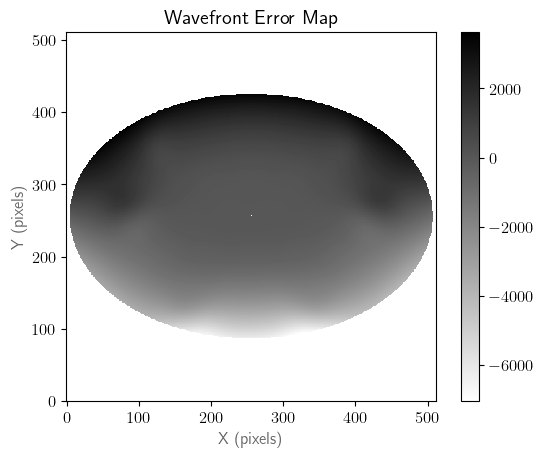

In [6]:
plt.figure()
plt.imshow(result.raw, cmap="gray_r", interpolation="none", origin="lower")
plt.title("Wavefront Error Map")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.colorbar()
plt.show()

In [7]:
from stop_utils.visualization import plot_wfe_data

In [8]:
# from photutils.aperture import EllipticalAperture

# aperture = EllipticalAperture(
#     (params.x0, params.y0), params.a, params.b, theta=params.theta
# )

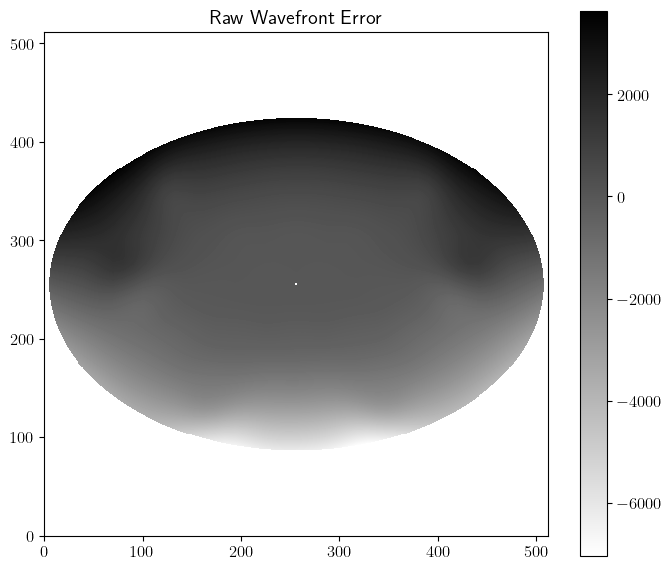

In [9]:
plot_wfe_data(
    result.raw,
    aperture=None,
    title="Raw Wavefront Error",
    output_path=None,
    zoom=1,
    cmap="gray_r",
)

In [10]:
OUTPUT_DIR = "/export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data"
output_path = f"{OUTPUT_DIR}/deleteme"

# Using Python's subprocess to run the shell command
from subprocess import run
run(["stop-utils", "analyze", wfe_path, output_path, "-n", "36", "-f", "zemax"])

⠙  Analyzing   

2025-04-19 23:43:58 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:213 - Analyzing WFE data from /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:58 | INFO     | stop_utils.wfe_analysis:load_wfe_data:31 - Using specified Zemax file format.
2025-04-19 23:43:58 | INFO     | stop_utils.converters:load_zemax_wfe:37 - Reading Zemax WFE file: /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt
2025-04-19 23:43:58 | INFO     | stop_utils.converters:load_zemax_wfe:101 - Successfully loaded and converted data from /home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt


⠙  Plotting    

2025-04-19 23:44:00 | INFO     | stop_utils.wfe_analysis:analyze_wfe_data:240 - Analysis complete - RMS error: 124.12 nm
2025-04-19 23:44:00 | INFO     | stop_utils.visualization:generate_plots:116 - Generating plots in /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme with format=png
2025-04-19 23:44:00 | INFO     | stop_utils.visualization:generate_plots:133 - Calculated zoom factor: 1


⠸  Plotting    

Analysis complete!
  Polynomial Coefficients (standard ordering, normalize = False)  
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Mode ┃ Orthonormal Coefficient (nm) ┃ Zernike Coefficient (nm) ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  0   │                     -274.969 │                 -594.201 │
│  1   │                     -109.507 │                 -130.848 │
│  2   │                     1705.245 │                 4185.728 │
│  3   │                      245.182 │                 2605.737 │
│  4   │                     -245.740 │                -1059.760 │
│  5   │                       39.844 │                  286.792 │
│  6   │                       -9.296 │                  340.083 │
│  7   │                      -38.244 │                 -222.332 │
│  8   │                      571.501 │                 4596.964 │
│  9   │                     -234.449 │                 1121.689 │
│  10  │                  

2025-04-19 23:44:02 | INFO     | stop_utils.visualization:generate_plots:184 - All plots generated successfully
2025-04-19 23:44:02 | SUCCESS  | stop_utils.cli:run_analysis:172 - Analysis completed successfully
2025-04-19 23:44:02 | INFO     | stop_utils.cli:run_analysis:180 - Results:
  Raw WFE RMS: 1872.52
  Fit WFE RMS: 1868.40
  Fit WFE RMS (-PTT): 755.69
  Fit WFE RMS (-PTTF): 714.81
  Residual RMS: 124.12 nm
  Residual PTP: 1229.09 nm

Ellipse parameters:
  Center: (256.0, 255.4)
  Semi-axes: (251.3, 169.3)
  Angle: 3.142 rad
2025-04-19 23:44:02 | INFO     | stop_utils.cli:run_analysis:202 - Output files:
  Plots: /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme
  Coefficients: /export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme/polynomial_coefficients.json


CompletedProcess(args=['stop-utils', 'analyze', '/home/ariel/andrea.bocchieri/DATA/Optics/STOP/STOP-utils/data/zemax/ARIEL - STOP Analysis - FC - C17.txt', '/export/NAS/ariel/data/andrea.bocchieri/Optics/STOP/data/deleteme', '-n', '36', '-f', 'zemax'], returncode=0)